#Análise de dados - Portal da Transparência 2025

In [ ]:
ano = 2025
caminho_dados = f'/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/{ano}_Viagem.csv'
caminho_saida_tabela = f'/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/output/tabela_{ano}.xlsx'
caminho_saida_grafico = f'/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/output/grafico_{ano}.png'


In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
#Lendo os dados
df_viagens = pd.read_csv(caminho_dados, encoding='Windows-1252', sep =';' , decimal = "," )


In [ ]:
#Criando uma coluna "Despesa" na tabela
df_viagens['Despesas'] = df_viagens['Valor diárias'] + df_viagens['Valor passagens'] + df_viagens['Valor outros gastos']

In [ ]:
#Ajustando valores nulos na coluna "Cargo"
df_viagens['Cargo'] = df_viagens['Cargo'].fillna("NÃO INDENTIFICADO")

In [ ]:
#Convertendo as colunas de String em datas

df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format = "%d/%m/%Y")
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'], format = "%d/%m/%Y")

In [ ]:
#Criando novas colunas de datas "Mês da viagem" & "Dias de viagem"
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days

In [ ]:
#Criando tabela consolidada
df_viagens_consolidado = (df_viagens.groupby('Cargo')).agg(
    despedia_media = ('Despesas' , 'mean'),
    duracao_media = ('Dias de viagem' , 'mean'),
    despesas_totais = ('Despesas', 'sum'),
    destino_mais_frequente = ('Destinos', pd.Series.mode),
    n_viagens = ('Nome', 'count')

    ).reset_index().sort_values(by = 'despesas_totais', ascending=False)


In [ ]:
#Filtrando os valores da tabela consolidada por Cargos relevantes(>1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtros = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)


In [ ]:
#Tabela final - consolidada e filtrada
df_final = df_viagens_consolidado[filtros].sort_values(by='n_viagens', ascending=False)

#Salvando a tabela final
df_final.to_excel(caminho_saida_tabela, index=False)

In [ ]:
df_final = df_viagens_consolidado[filtros]

# Criando e customizando gráfico com Pandas

In [ ]:
df_final

,Cargo,despedia_media,duracao_media,despesas_totais,destino_mais_frequente,n_viagens
547,NÃO INDENTIFICADO,3780.10,7.53,1130919022.95,Brasília/DF,299177
498,Informações protegidas por sigilo,3715.24,7.88,420906919.84,Informações protegidas por sigilo,113292
634,PROFESSOR DO MAGISTERIO SUPERIOR,2217.78,3.69,118052206.62,Brasília/DF,53230
635,PROFESSOR ENS BASICO TECN TECNOLOGICO,1574.71,2.31,62268817.77,Brasília/DF,39543
760,TECNICO DO SEGURO SOCIAL,5011.92,12.34,50324664.59,Brasília/DF,10041
97,ANALISTA AMBIENTAL,2983.69,5.45,49344187.94,Brasília/DF,16538
247,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,2892.54,2.92,25497736.25,Brasília/DF,8815
246,AUDITOR FISCAL FEDERAL AGROPECUARIO,1473.45,1.96,25384546.02,Brasília/DF,17228
211,ASSISTENTE EM ADMINISTRAçãO,1512.76,2.17,16850600.71,Brasília/DF,11139
137,ANALISTA TRIBUTARIO REC FEDERAL BRASIL,1965.77,3.29,16600897.27,Brasília/DF,8445


<Axes: xlabel='Cargo'>

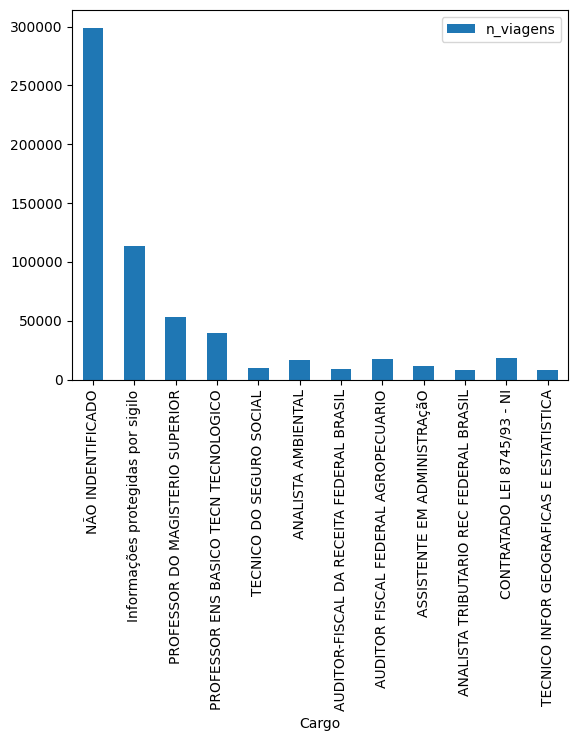

In [ ]:
df_final.plot(x= 'Cargo', y='n_viagens', kind = "bar")

#Criando e customizando gráfico com matplotlib
##Numero de viagens por cargos

In [ ]:
import matplotlib.pyplot as plt

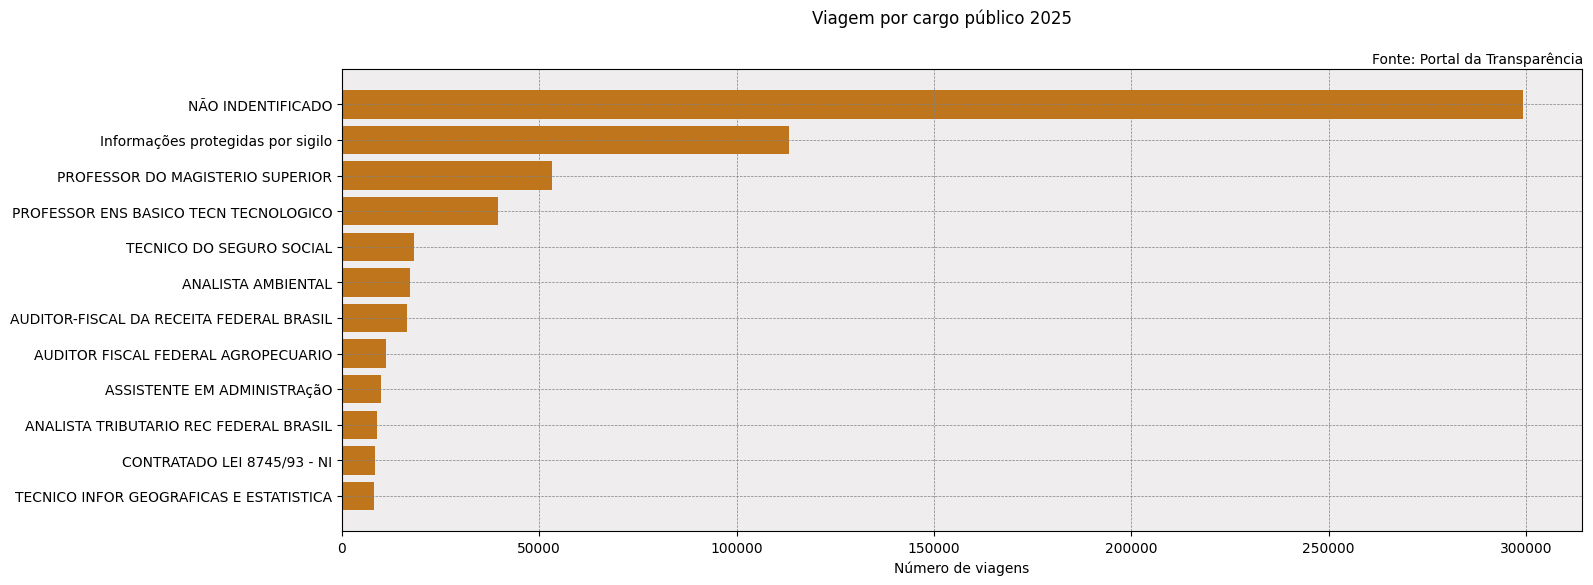

In [ ]:
from matplotlib.lines import lineStyles

df_plot = df_final.sort_values(by='n_viagens', ascending=False)
fig, ax = plt.subplots(figsize=(16, 6)) # gera o grafico no centro + o tamanho da figura

ax.barh(df_final['Cargo'], df_plot['n_viagens'], color='#bf751b') #Gera um grafico de barras na horizontal e define o Cargo é no eixo X e n_viagens no eixo Y E a cor das barras
ax.invert_yaxis() #inverte o eixo Y do gráfico
ax.set_facecolor('#f0edee') #define a cor do fundo do gráfico

fig.suptitle('Viagem por cargo público 2025') #add um titulo ao gráfico

plt.figtext(0.769, 0.89, "Fonte: Portal da Transparência")# Adiciona um texto fora do gráfico

plt.grid(color= 'gray', linestyle = '--', linewidth= 0.5) # Ativa a grade do gráfico com linhas cinzas, tracejadas e finas
plt.yticks(fontsize=10) # Define o tamanho da fonte dos cargos do eixo Y em 10

plt.xlabel("Número de viagens") #add uma legenda no eixo X

plt.savefig(caminho_saida_grafico, bbox_inches ='tight')#Salvando o grafico

#Explorando dados e união de tabelas

In [ ]:
df_viagens


,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
0,20150776,060767/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52111,Comando da Aeronáutica,***.566.948-**,PETERSON RODRIGUES DA SILVA SANTOS,NÃO INDENTIFICADO,Sargento,Sargentos,2025-09-29,2025-10-30,Guaratinguetá/SP,Curso de Preparação de Instrutores para Gradua...,0.00,0.00,0.00,0.00,0.00,September,31
1,20261730,000086/25-1C,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26236,Universidade Federal Fluminense,***.834.907-**,NAZIRA CORREIA CAMELY,PROFESSOR DO MAGISTERIO SUPERIOR,-1,Sem informação,2025-03-01,2025-08-04,Rio Branco/AC,Desenvolvimento da pesquisa que desenvolvo na ...,0.00,0.00,0.00,0.00,0.00,March,156
2,20286869,000002/25,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26241,Universidade Federal do Paraná,***.235.999-**,ALMIR MANOEL CUNICO,PROFESSOR DO MAGISTERIO SUPERIOR,FG-0001,FG-0001,2025-01-25,2025-02-01,Palmas/TO,PARTICIPAÇÃO DO XXV ENCONTRO BRASILEIRO DE ICT...,0.00,2544.74,0.00,0.00,2544.74,January,7
3,20289421,000001/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.396.790-**,ROMULO FABIANO PACHECO RAVAZIO,NÃO INDENTIFICADO,OfSuperior,OfSuperior,2025-01-05,2025-01-07,"Bogotá/Colômbia, Uberlândia/MG",Movimentação de militar por término de missão ...,0.00,4329.72,0.00,1240.09,5569.81,January,2
4,20289650,000004/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.329.397-**,ALFREDO DIAS DE OLIVEIRA JUNIOR,NÃO INDENTIFICADO,Subtenente,Subtenentes,2025-01-04,2025-01-06,"Londres/Reino Unido, Brasília/DF",Movimentação de militar por término de missão ...,0.00,7109.73,0.00,1053.53,8163.26,January,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801010,2025002573,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.342.565-**,CLIMERIO LEITE PEREIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2025-12-15,2025-12-16,Sem informação,Assessorar Difis em reuniões em SP.,1204.09,5424.29,0.00,0.00,6628.38,December,1
801011,2025002576,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.283.875-**,AILTON DE AQUINO SANTOS,DIRETOR SERVIDOR DO BANCO CENTRAL,-1,Sem informação,2025-12-14,2025-12-16,Sem informação,O Diretor de Fiscalização cumprirá agenda em S...,1909.09,4729.59,0.00,0.00,6638.68,December,2
801012,2025002580,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.869.121-**,DIOGO SOUZA CARMO NOGUEIRA,ANALISTA DO BANCO CENTRAL,-1,Sem informação,2025-12-22,2025-12-26,Sem informação,Cumprir agenda de trabalhos em São Paulo.,2613.18,0.00,0.00,0.00,2613.18,December,4
801013,2025002645,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.827.438-**,GABRIEL MURICCA GALIPOLO,PRESIDENTE DO BANCO CENTRAL,-1,Sem informação,2025-12-31,2026-01-05,Sem informação,"Cumprir agenda no Banco Central em São Paulo, ...",1863.64,4073.21,0.00,0.00,5936.85,December,5


Text(0, 0.5, 'Despesas (R$)')

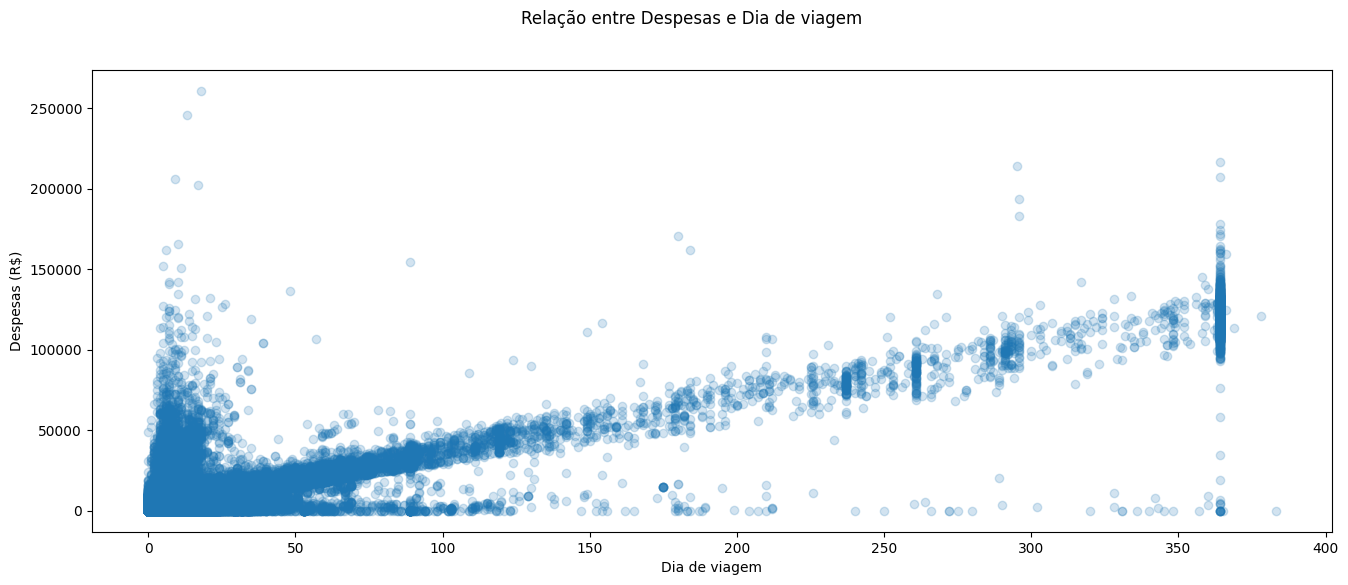

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))# add uma figura e um eixo para o gráfico, definindo o tamanho como 16x6 polegadas

ax.scatter(df_viagens['Dias de viagem'], df_viagens['Despesas'], alpha=0.2) # Cria um gráfico 'scatter plot' relacionando o # eixo X=Dias de viagem e eixo Y=Despesas --- o alpha=0.2 deixa os pontos mais transparentes
fig.suptitle('Relação entre Despesas e Dia de viagem')
plt.xlabel("Dia de viagem") #add uma legenda no eixo X
plt.ylabel("Despesas (R$)") #add uma legenda no eixo Y


### Filtrando quais as viagens tiveram uma Despesa + 175000

In [ ]:
(df_viagens['Despesas'] >175_000).value_counts() #Verifica se o valor da coluna 'Despesas' é maior que 175.000 e conta quantas vezes cada valor aparece


,count
Despesas,
False,801005
True,10


In [ ]:
filtro = df_viagens['Despesas'] > 175_000 # Cria um filtro boolean
df_viagens[filtro]

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem
427,20557147,000836/25-26C,Realizada,SIM,Conforme Diárias e Passagens e autorizações em...,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,***.096.192-**,JULYANA DOS SANTOS COELHO,NÃO INDENTIFICADO,-1,Sem informação,2025-01-01,2025-12-31,"Brasília/DF, Rio Branco/AC, Cruzeiro do Sul/AC...",Em continuidade à PCDP: 001178/24. Centro de C...,128253.75,88475.61,0.00,0.00,216729.36,January,364
1690,20648908,001041/25-8C,Realizada,SIM,Devido a necessidade de emprego e recomposição...,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,***.731.648-**,PAULO PEDRO DA SILVA,NÃO INDENTIFICADO,-1,Sem informação,2025-01-01,2025-10-24,"Capitão Poço/PA, Capitão Poço/PA, Imperatriz/M...",Continuidade da PCDP nº 1156/24 tendo em vista...,180397.50,2671.00,0.00,0.00,183068.50,January,296
1721,20649880,001382/25-19C,Realizada,SIM,Conforme Diárias e Passagens.,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,***.468.361-**,BRUNO REZENDE CABRAL,NÃO INDENTIFICADO,-1,Sem informação,2025-01-01,2025-12-31,"Brasília/DF, Rio de Janeiro/RJ, Angra dos Reis...",Em continuidade à PCDP: 000844/24. Centro de C...,131078.75,76141.39,0.00,0.00,207220.14,January,364
4571,20678030,000042/25-10C,Realizada,SIM,Por indisponibilidade de recursos orçamentário.,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,***.179.313-**,JORGE LUIZ FELIX REBOUCAS,NÃO INDENTIFICADO,-1,Sem informação,2025-01-01,2025-10-24,"Rio de Janeiro/RJ, Rio de Janeiro/RJ, Tucumã/P...",Continuidade da PCDP nº 1402/24 tendo em vista...,190005.00,3653.60,0.00,0.00,193658.60,January,296
7515,20686417,Informações p,Realizada,NÃO,Informação protegida por sigilo nos termos da ...,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,ID268906416,Informações protegidas por sigilo,Informações protegidas por sigilo,-11,Informações protegidas por sigilo,2025-01-01,2025-12-31,Informações protegidas por sigilo,Informação protegida por sigilo nos termos da ...,125973.95,52255.25,0.00,0.00,178229.20,January,364
10508,20690771,000015/25,Realizada,SIM,Justifica-se em razão da confirmação da viagem...,32000,Ministério de Minas e Energia,32000,Ministério de Minas e Energia - Unidades com v...,***.100.897-**,PIETRO ADAMO SAMPAIO MENDES,ESP REG DE PET E DER ALC COMB E GAS NAT,CCX-0117,CCX-0117,2025-01-08,2025-01-21,"Abu Dabi/Emirados Árabes, Riad/Arábia Saudita,...",Justifica-se em razão da necessidade de acompa...,15775.96,229149.22,0.00,927.62,245852.80,January,13
43101,20733847,Informações p,Realizada,NÃO,Informação protegida por sigilo nos termos da ...,30000,Ministério da Justiça e Segurança Pública,30000,Ministério da Justiça e Segurança Pública - Un...,ID003400209,Informações protegidas por sigilo,Informações protegidas por sigilo,-11,Informações protegidas por sigilo,2025-01-09,2025-10-31,Informações protegidas por sigilo,Informação protegida por sigilo nos termos da ...,213987.50,0.00,0.00,0.00,213987.50,January,295
186670,20914280,005196/25-1C,Realizada,SIM,Atender demanda do CEMCFA,52000,Ministério da Defesa,52000,Ministério da Defesa - Unidades com vínculo di...,***.690.907-**,RENATO RODRIGUES DE AGUIAR FREIRE,NÃO INDENTIFICADO,CCX-0118,CCX-0118,2025-05-16,2025-06-03,Cingapura/Cingapura,Cerimônia de abertura do Defense and Security ...,38325.97,220393.54,590.94,1976.95,260696.46,May,18
223386,20961121,001706/25,Realizada,SIM

##Importando a tabela "Passagens"

In [ ]:
caminho_dados_passagens = "/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/2025_Passagem.csv"
df_passagens = pd.read_csv(caminho_dados_passagens, encoding='Windows-1252', sep =';' , decimal = "," )
df_passagens

,Identificador do processo de viagem,Número da Proposta (PCDP),Meio de transporte,País - Origem ida,UF - Origem ida,Cidade - Origem ida,País - Destino ida,UF - Destino ida,Cidade - Destino ida,País - Origem volta,UF - Origem volta,Cidade - Origem volta,Pais - Destino volta,UF - Destino volta,Cidade - Destino volta,Valor da passagem,Taxa de serviço,Data da emissão/compra,Hora da emissão/compra
0,20286869,000002/25,Aéreo,Brasil,Tocantins,Palmas,Brasil,Paraná,Maringá,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1272.97,0.00,17/09/2024,11:43
1,20286869,000002/25,Aéreo,Brasil,Paraná,Maringá,Brasil,Tocantins,Palmas,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1271.77,0.00,17/09/2024,11:43
2,20289421,000001/25,Aéreo,Colômbia,NaN,Bogotá,Brasil,Minas Gerais,Uberlândia,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,4329.72,0.00,17/10/2024,14:46
3,20289650,000004/25,Aéreo,Reino Unido,NaN,Londres,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,7109.73,0.00,07/10/2024,16:34
4,20289787,000003/25,Aéreo,Reino Unido,NaN,Londres,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,7109.73,0.00,07/10/2024,16:35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412360,2025002576,Sem informaçã,Aéreo,Brasil,São Paulo,São Paulo,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,2617.82,0.00,NaN,00:00
412361,2025002645,Sem informaçã,Aéreo,Brasil,Distrito Federal,Brasília,Brasil,São Paulo,São Paulo,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,2200.77,0.00,NaN,00:00
412362,2025002645,Sem informaçã,Aéreo,Brasil,São Paulo,São Paulo,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1872.44,0.00,NaN,00:00
412363,2025002646,Sem informaçã,Aéreo,Brasil,Distrito Federal,Brasília,Brasil,São Paulo,São Paulo,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1817.77,0.00,NaN,00:00


## Cruzando informações das tabelas Viagem e Passagens


In [ ]:
df_passagens[df_passagens['Identificador do processo de viagem'] == 21310516] #Criando um filtro, onde é filtrado pela coluna 'Identificador do processo de viagem' e mostra onde o valor 21310516 aparece

,Identificador do processo de viagem,Número da Proposta (PCDP),Meio de transporte,País - Origem ida,UF - Origem ida,Cidade - Origem ida,País - Destino ida,UF - Destino ida,Cidade - Destino ida,País - Origem volta,UF - Origem volta,Cidade - Origem volta,Pais - Destino volta,UF - Destino volta,Cidade - Destino volta,Valor da passagem,Taxa de serviço,Data da emissão/compra,Hora da emissão/compra
270410,21310516,001064/25,Aéreo,China,NaN,Beijing,Austrália,NaN,Sydney,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,35561.51,0.00,29/08/2025,15:11
270411,21310516,001064/25,Aéreo,Etiópia,NaN,Adis-Ababa,China,NaN,Beijing,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,34897.41,0.00,29/08/2025,15:10
270412,21310516,001064/25,Aéreo,Austrália,NaN,Sydney,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,36440.88,0.00,29/08/2025,15:11
270413,21310516,001064/25,Aéreo,Índia,NaN,Nova Delhi,Etiópia,NaN,Adis-Ababa,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,15718.78,0.00,29/08/2025,15:10
270414,21310516,001064/25,Aéreo,Brasil,Distrito Federal,Brasília,Índia,NaN,Nova Delhi,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,51667.32,0.00,29/08/2025,15:09


In [ ]:
df_viagens.merge(df_passagens) #Combinando as tabela 'Viagens' e 'Passagens'

,Identificador do processo de viagem,Número da Proposta (PCDP),Situação,Viagem Urgente,Justificativa Urgência Viagem,Código do órgão superior,Nome do órgão superior,Código órgão solicitante,Nome órgão solicitante,CPF viajante,Nome,Cargo,Função,Descrição Função,Período - Data de início,Período - Data de fim,Destinos,Motivo,Valor diárias,Valor passagens,Valor devolução,Valor outros gastos,Despesas,Mês da viagem,Dias de viagem,Meio de transporte,País - Origem ida,UF - Origem ida,Cidade - Origem ida,País - Destino ida,UF - Destino ida,Cidade - Destino ida,País - Origem volta,UF - Origem volta,Cidade - Origem volta,Pais - Destino volta,UF - Destino volta,Cidade - Destino volta,Valor da passagem,Taxa de serviço,Data da emissão/compra,Hora da emissão/compra
0,20286869,000002/25,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26241,Universidade Federal do Paraná,***.235.999-**,ALMIR MANOEL CUNICO,PROFESSOR DO MAGISTERIO SUPERIOR,FG-0001,FG-0001,2025-01-25,2025-02-01,Palmas/TO,PARTICIPAÇÃO DO XXV ENCONTRO BRASILEIRO DE ICT...,0.00,2544.74,0.00,0.00,2544.74,January,7,Aéreo,Brasil,Tocantins,Palmas,Brasil,Paraná,Maringá,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1272.97,0.00,17/09/2024,11:43
1,20286869,000002/25,Realizada,NÃO,Sem informação,26000,Ministério da Educação,26241,Universidade Federal do Paraná,***.235.999-**,ALMIR MANOEL CUNICO,PROFESSOR DO MAGISTERIO SUPERIOR,FG-0001,FG-0001,2025-01-25,2025-02-01,Palmas/TO,PARTICIPAÇÃO DO XXV ENCONTRO BRASILEIRO DE ICT...,0.00,2544.74,0.00,0.00,2544.74,January,7,Aéreo,Brasil,Paraná,Maringá,Brasil,Tocantins,Palmas,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,1271.77,0.00,17/09/2024,11:43
2,20289421,000001/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.396.790-**,ROMULO FABIANO PACHECO RAVAZIO,NÃO INDENTIFICADO,OfSuperior,OfSuperior,2025-01-05,2025-01-07,"Bogotá/Colômbia, Uberlândia/MG",Movimentação de militar por término de missão ...,0.00,4329.72,0.00,1240.09,5569.81,January,2,Aéreo,Colômbia,NaN,Bogotá,Brasil,Minas Gerais,Uberlândia,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,4329.72,0.00,17/10/2024,14:46
3,20289650,000004/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.329.397-**,ALFREDO DIAS DE OLIVEIRA JUNIOR,NÃO INDENTIFICADO,Subtenente,Subtenentes,2025-01-04,2025-01-06,"Londres/Reino Unido, Brasília/DF",Movimentação de militar por término de missão ...,0.00,7109.73,0.00,1053.53,8163.26,January,2,Aéreo,Reino Unido,NaN,Londres,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,7109.73,0.00,07/10/2024,16:34
4,20289787,000003/25,Realizada,NÃO,Sem informação,52000,Ministério da Defesa,52121,Comando do Exército,***.012.377-**,FRANCISCA LEILA DE PAULA VIEIRA DE OLIVEIRA,NÃO INDENTIFICADO,-1,Sem informação,2025-01-04,2025-01-06,"Londres/Reino Unido, Brasília/DF",DEPENDENTE (Esposa) do S Ten Inf ALFREDO DIAS ...,0.00,7109.73,0.00,0.00,7109.73,January,2,Aéreo,Reino Unido,NaN,Londres,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,Sem informação,7109.73,0.00,07/10/2024,16:35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412384,2025002576,Sem informaçã,Realizada,NÃO,Sem informação,25201,Banco Central do Brasil - Orçamento Fiscal e S...,25201,Banco Central do Brasil - Orçamento Fiscal e S...,***.283.875-**,AILTON DE AQUINO SANTOS,DIRETOR SERVIDOR DO BANCO CENTRAL,-1,Sem informação,2025-12-14,2025-12-16,Sem informação,O Diretor de Fiscalização cumprirá agenda em S...,1909.09,4729.59,0.00,0.00,6638.68,December,2,Aéreo,Brasil,São Paulo,São Paulo,Brasil,Distrito Federal,Brasília,Sem informação,Sem informação,Sem informação,S

#Salvando as Tabelas + Gráficos

In [ ]:
caminho_saida = '/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/output/tabela.xlsx'


In [ ]:
df_final.to_excel(caminho_saida, index=False) #salvando a tabela no formato xlxs na pasta 'output' no drive

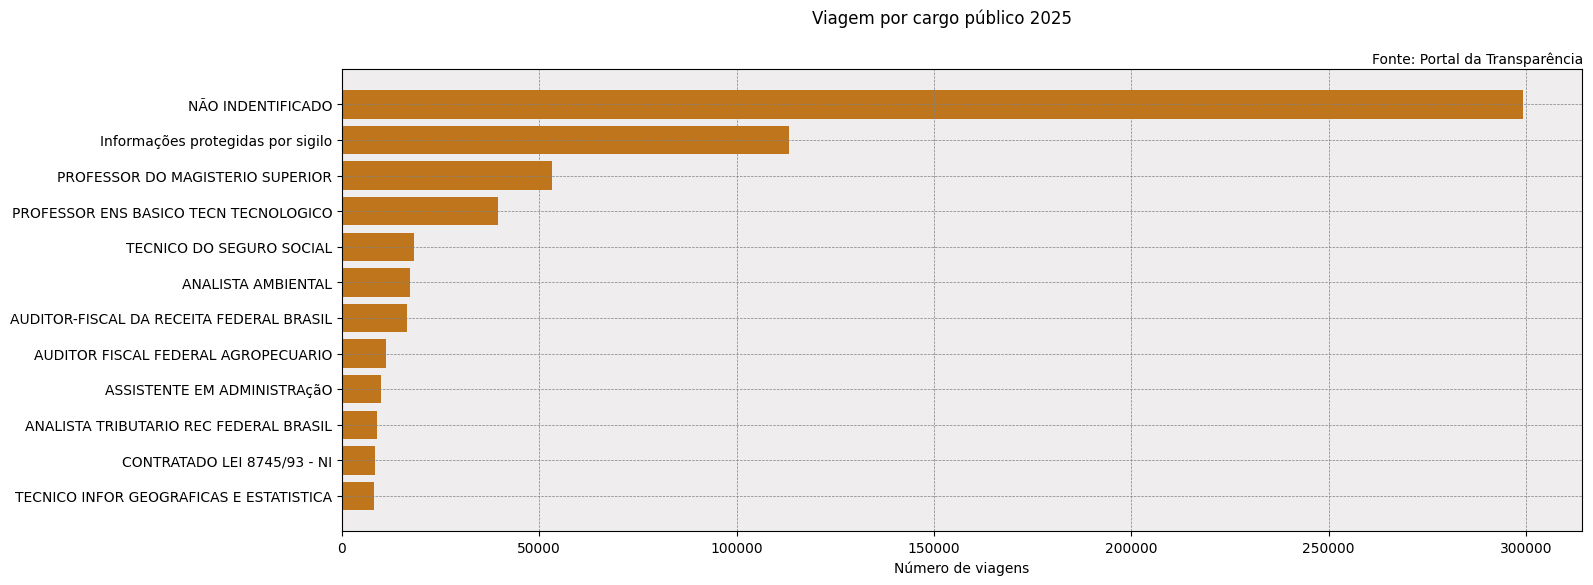

In [ ]:
import matplotlib.pyplot as plt

caminho_figura = '/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/output/figura.png' #salvando a figura na pasta output

from matplotlib.lines import lineStyles

df_plot = df_final.sort_values(by='n_viagens', ascending=False)
fig, ax = plt.subplots(figsize=(16, 6)) # Plotando o grafico no centro + o tamanho da figura

ax.barh(df_final['Cargo'], df_plot['n_viagens'], color='#bf751b') #Gera um grafico de barras na horizontal e define o Cargo é no eixo X e n_viagens no eixo Y E a cor das barras
ax.invert_yaxis() #inverte o eixo Y do gráfico
ax.set_facecolor('#f0edee') #define a cor do fundo do gráfico

fig.suptitle('Viagem por cargo público 2025') #add um titulo ao gráfico

plt.figtext(0.769, 0.89, "Fonte: Portal da Transparência")# Adiciona um texto fora do gráfico

plt.grid(color= 'gray', linestyle = '--', linewidth= 0.5) # Ativa a grade do gráfico com linhas cinzas, tracejadas e finas
plt.yticks(fontsize=10) # Define o tamanho da fonte dos cargos do eixo Y em 10

plt.xlabel("Número de viagens") #add uma legendo no eixo X

plt.savefig(caminho_figura, bbox_inches  = 'tight')#salvando a figura com formatação correta

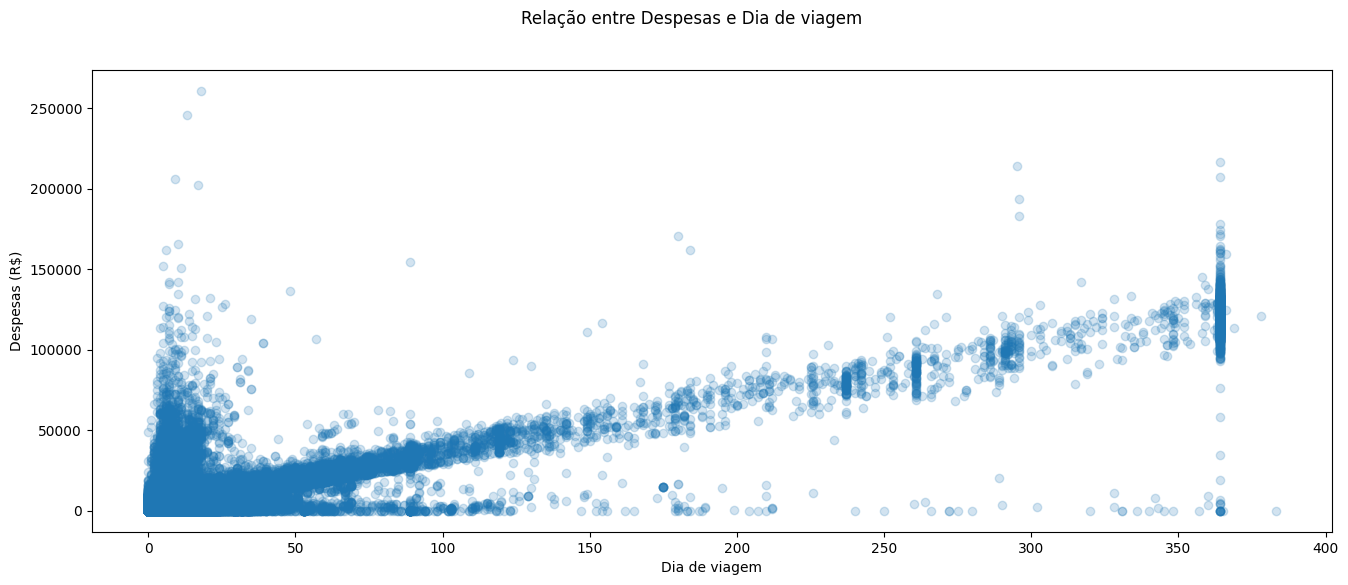

In [ ]:
import matplotlib.pyplot as plt

caminho_figura_scatter = '/content/drive/MyDrive/Analise de Dados - Portal da transparência 2025/output/scatter.png' #salvando a figura na pasta output

fig, ax = plt.subplots(figsize=(16, 6))# add uma figura e um eixo para o gráfico, definindo o tamanho como 16x6 polegadas

ax.scatter(df_viagens['Dias de viagem'], df_viagens['Despesas'], alpha=0.2) # Cria um gráfico 'scatter plot' relacionando o # eixo X=Dias de viagem e eixo Y=Despesas --- o alpha=0.2 deixa os pontos mais transparentes
fig.suptitle('Relação entre Despesas e Dia de viagem')
plt.xlabel("Dia de viagem") #add uma legenda no eixo X
plt.ylabel("Despesas (R$)") #add uma legenda no eixo Y

plt.savefig(caminho_figura, bbox_inches  = 'tight')#salvando a figura com formatação correta

